# 03. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS)

## MỤC LỤC
1. [Import thư viện & Đọc dữ liệu](#1-import-thư-viện--đọc-dữ-liệu)
2. [Phân tích Nhân khẩu học (Demographics Analysis)](#2-phân-tích-nhân-khẩu-học-demographics-analysis)
   - 2.1. Phân bố kết quả học tập theo Nhóm tuổi, Giới tính và Trình độ học vấn
   - 2.2. Đánh giá & Định hướng xử lý (Markdown)
3. [Phân tích Hành vi tương tác VLE & Điểm số (Activity & Performance Analysis)](#3-phân-tích-hành-vi-tương-tác-vle--điểm-số-activity--performance-analysis)
   - 3.1. Phân bố lượt click và điểm trung bình quá trình
   - 3.2. Trực quan hóa bằng Boxplot & Histogram
   - 3.3. Đánh giá & Định hướng xử lý (Markdown)
4. [Phân tích Chuỗi thời gian & Xu hướng rút lui (Temporal & Withdrawal Analysis)](#4-phân-tích-chuỗi-thời-gian--xu-hướng-rút-lui-temporal--withdrawal-analysis)
   - 4.1. Xu hướng tương tác VLE hàng tuần theo nhóm kết quả
   - 4.2. Phân bố thời điểm sinh viên hủy đăng ký (`Withdrawn`) theo tuần
   - 4.3. Đánh giá & Định hướng xử lý (Markdown)
5. [Phân tích Nộp bài trễ hạn (Assessment Patterns)](#5-phân-tích-nộp-bài-trễ-hạn-assessment-patterns)
   - 5.1. Thống kê bài nộp trễ theo nhóm kết quả
   - 5.2. Đánh giá & Định hướng xử lý (Markdown)
6. [Heatmap Tương quan giữa các Đặc trưng số (Correlation Matrix)](#6-heatmap-tương-quan-giữa-các-đặc-trưng-số-correlation-matrix)
   - 6.1. Ma trận tương quan Pearson
   - 6.2. Đánh giá khả năng phân tách của các Feature đối với mô hình Machine Learning
7. [Tổng kết & Danh sách Feature chốt đưa vào File 04](#7-tổng-kết--danh-sách-feature-chốt-đưa-vào-file-04)

---

## 1. Import thư viện & Đọc dữ liệu

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc các file dữ liệu OULAD
student_info = pd.read_csv('data/studentInfo.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')
assessments = pd.read_csv('data/assessments.csv')
student_vle = pd.read_csv('data/studentVle.csv')
vle = pd.read_csv('data/vle.csv')
student_registration = pd.read_csv('data/studentRegistration.csv')

print("Đã tải dữ liệu thành công!")

Đã tải dữ liệu thành công!


## 2. Phân tích Nhân khẩu học (Demographics Analysis)

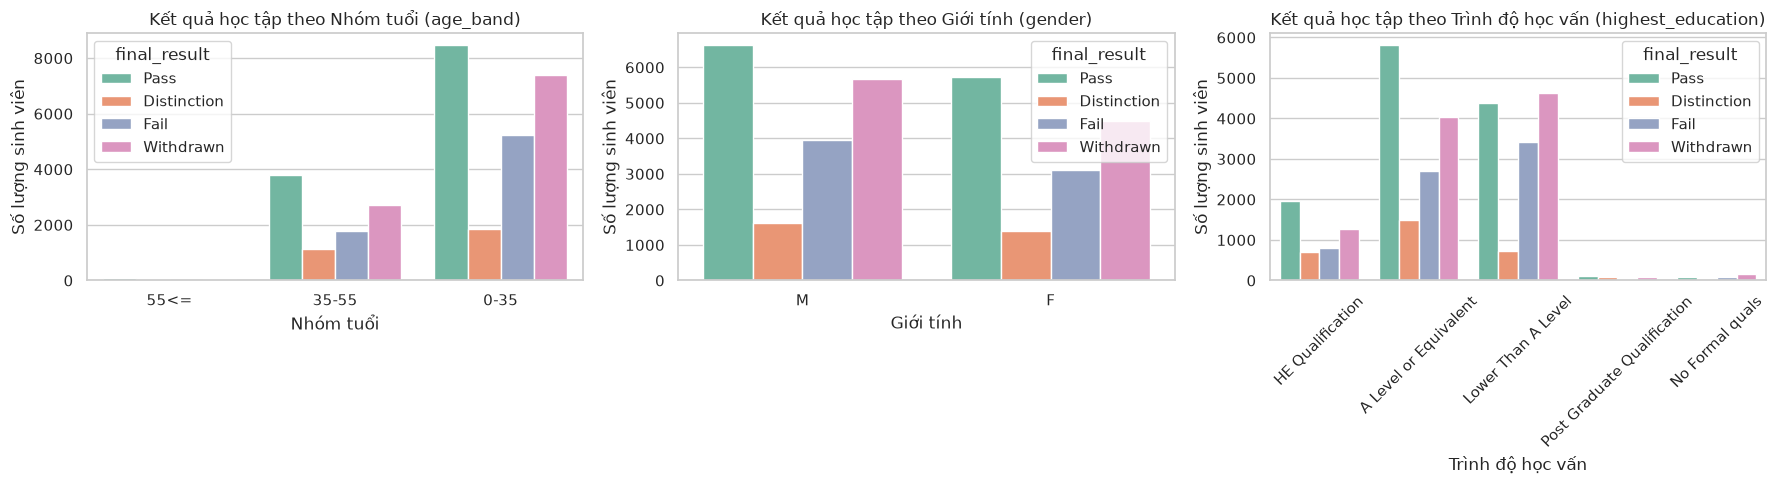

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Kết quả theo Độ tuổi
sns.countplot(data=student_info, x='age_band', hue='final_result', 
              hue_order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], palette='Set2', ax=axes[0])
axes[0].set_title('Kết quả học tập theo Nhóm tuổi (age_band)')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Số lượng sinh viên')

# Biểu đồ 2: Kết quả theo Giới tính
sns.countplot(data=student_info, x='gender', hue='final_result', 
              hue_order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], palette='Set2', ax=axes[1])
axes[1].set_title('Kết quả học tập theo Giới tính (gender)')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Số lượng sinh viên')

# Biểu đồ 3: Kết quả theo Học vấn
sns.countplot(data=student_info, x='highest_education', hue='final_result', 
              hue_order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], palette='Set2', ax=axes[2])
axes[2].set_title('Kết quả học tập theo Trình độ học vấn (highest_education)')
axes[2].set_xlabel('Trình độ học vấn')
axes[2].set_ylabel('Số lượng sinh viên')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

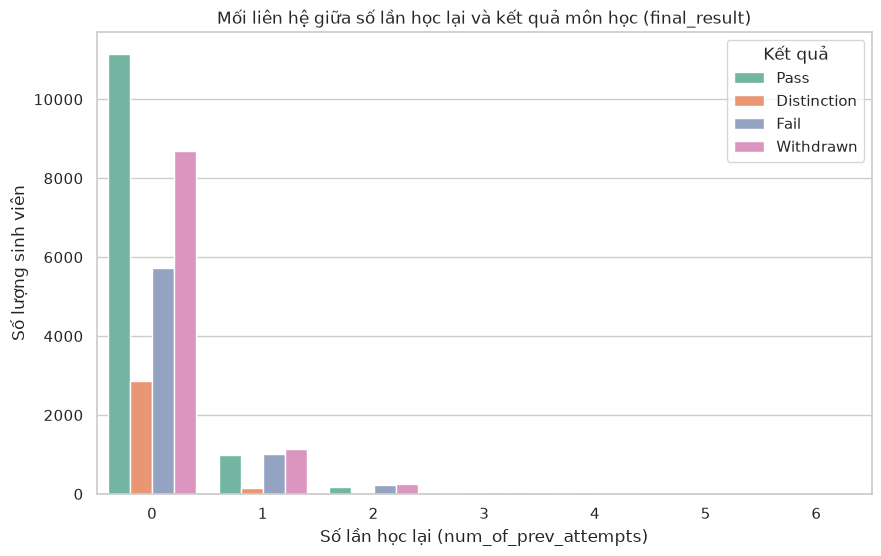

In [18]:
# Phân tích số lần học lại (num_of_prev_attempts) với kết quả cuối cùng
plt.figure(figsize=(10, 6))
sns.countplot(data=student_info, x='num_of_prev_attempts', hue='final_result',
              hue_order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], palette='Set2')
plt.title('Mối liên hệ giữa số lần học lại và kết quả môn học (final_result)')
plt.xlabel('Số lần học lại (num_of_prev_attempts)')
plt.ylabel('Số lượng sinh viên')
plt.legend(title='Kết quả')
plt.show()

> **2.2. Đánh giá & Định hướng:**
> - **Đặc điểm phân tách mục tiêu**: Các yếu tố nhân khẩu học thể hiện sự khác biệt nhẹ giữa các nhóm (ví dụ: nhóm sinh viên tuổi `55<=` có tỷ lệ Pass cao hơn; nhóm trình độ học vấn thấp `Lower Than A Level` có tỷ lệ Fail/Withdrawn cao hơn rõ rệt).
> - **Đề xuất Feature Engineering (File 4)**: CÓ NÊN GIỮ LẠI. Nên mã hóa (Encoding) `age_band`, `gender`, `highest_education` để làm feature nền tảng cho mô hình ML.

## 3. Phân tích Hành vi tương tác VLE & Điểm số (Activity & Performance Analysis)

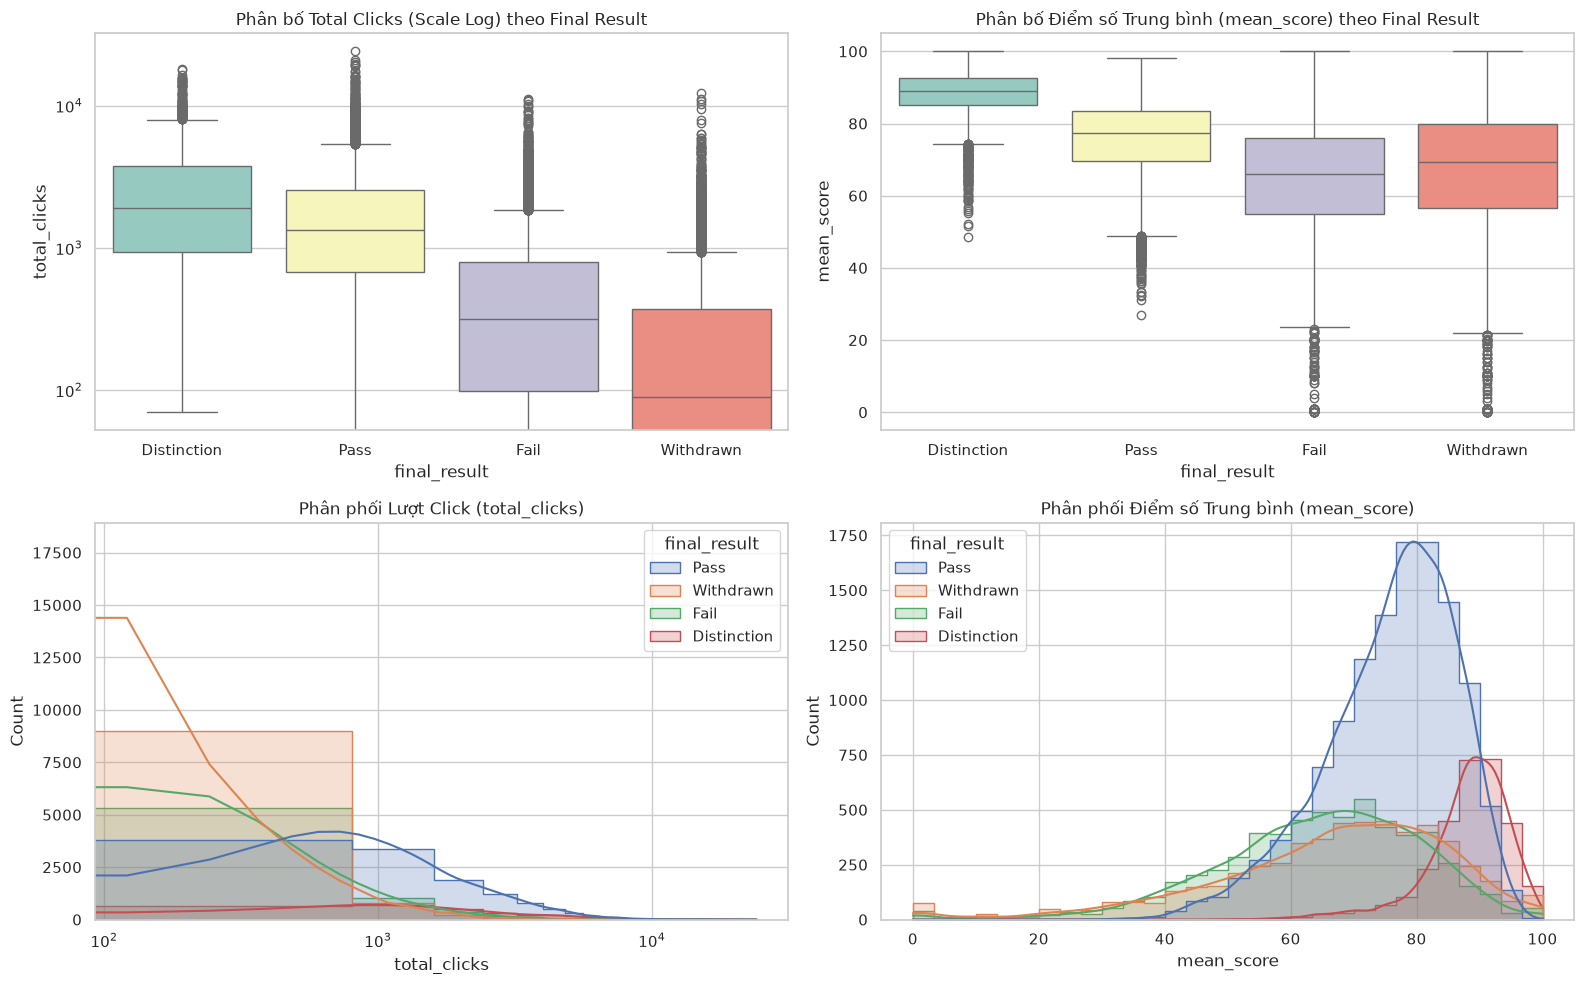

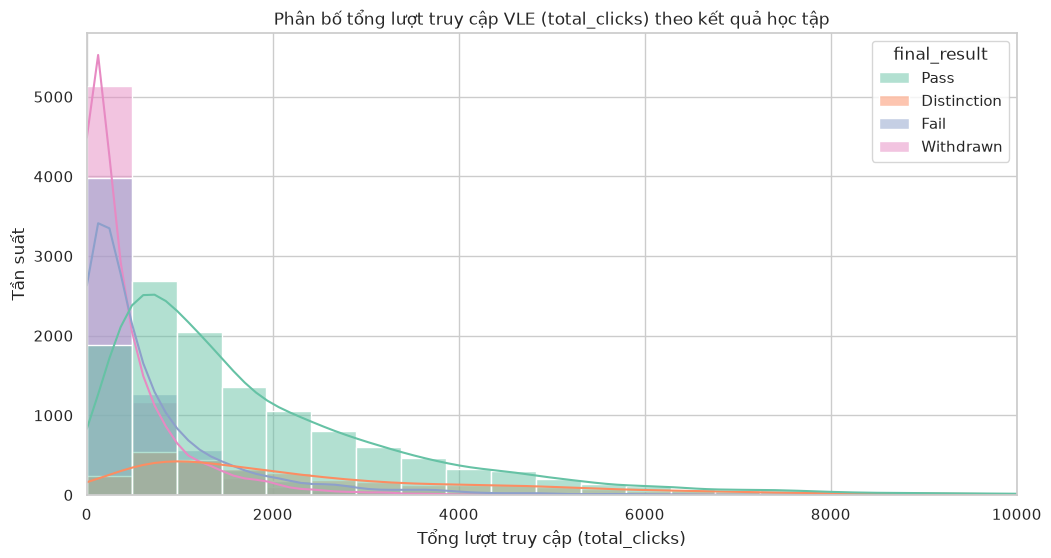

In [21]:
# 1. Tính total_clicks theo sinh viên
clicks_per_student = student_vle.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index()
clicks_per_student.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# Merge với student_info
df_clicks = pd.merge(student_info, clicks_per_student, on=['code_module', 'code_presentation', 'id_student'], how='left')
df_clicks['total_clicks'] = df_clicks['total_clicks'].fillna(0)

# 2. Tính điểm số trung bình quá trình (mean_score)
df_stu_score = pd.merge(student_assessment, assessments, on='id_assessment', how='inner')
mean_score_student = df_stu_score.groupby('id_student')['score'].mean().reset_index()
mean_score_student.rename(columns={'score': 'mean_score'}, inplace=True)

df_analysis = pd.merge(df_clicks, mean_score_student, on='id_student', how='left')

# Vẽ Boxplot & Histogram
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Boxplot total_clicks (Scale log để dễ quan sát do có outlier cao)
sns.boxplot(data=df_analysis, x='final_result', y='total_clicks', 
            order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], palette='Set3', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Phân bố Total Clicks (Scale Log) theo Final Result')

# Boxplot mean_score
sns.boxplot(data=df_analysis, x='final_result', y='mean_score', 
            order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], palette='Set3', ax=axes[0, 1])
axes[0, 1].set_title('Phân bố Điểm số Trung bình (mean_score) theo Final Result')

# Histogram total_clicks
sns.histplot(data=df_analysis, x='total_clicks', hue='final_result', element='step', kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Phân phối Lượt Click (total_clicks)')

# Histogram mean_score
sns.histplot(data=df_analysis, x='mean_score', hue='final_result', element='step', kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Phân phối Điểm số Trung bình (mean_score)')

plt.tight_layout()
plt.show()


# 1. Tính tổng số lượt truy cập (total_clicks) cho mỗi sinh viên
total_clicks_df = student_vle.groupby(['code_module', 'code_presentation', 'id_student'])['sum_click'].sum().reset_index(name='total_clicks')

# 2. Kết hợp với bảng student_info để lấy final_result
df_merged = pd.merge(student_info, total_clicks_df, on=['code_module', 'code_presentation', 'id_student'], how='left')

# 3. Vẽ Histogram cho phân bố tổng lượt truy cập
plt.figure(figsize=(12, 6))
sns.histplot(data=df_merged, x='total_clicks', hue='final_result', bins=50, kde=True,
             hue_order=['Pass', 'Distinction', 'Fail', 'Withdrawn'], palette='Set2')
plt.title('Phân bố tổng lượt truy cập VLE (total_clicks) theo kết quả học tập')
plt.xlabel('Tổng lượt truy cập (total_clicks)')
plt.ylabel('Tần suất')
plt.xlim(0, 10000) # Giới hạn trục x để loại bỏ outlier, giúp biểu đồ dễ nhìn hơn
plt.show()

> **3.3. Đánh giá & Định hướng:**
> - **Đặc điểm phân tách mục tiêu**: `total_clicks` và `mean_score` phân tách các lớp mục tiêu CỰC KỲ RÕ RỆT. Nhóm `Distinction` và `Pass` có trung vị lượt click và điểm quá trình vượt trội so với nhóm `Fail` và `Withdrawn`.
> - **Đề xuất Feature Engineering (File 4)**: BẮT BUỘC GIỮ LẠI. Cần log-transform cho `total_clicks` để xử lý hiện tượng lệch phải (skewness) và chuẩn hóa `mean_score`.

## 4. Phân tích Chuỗi thời gian & Xu hướng rút lui (Temporal & Withdrawal Analysis)

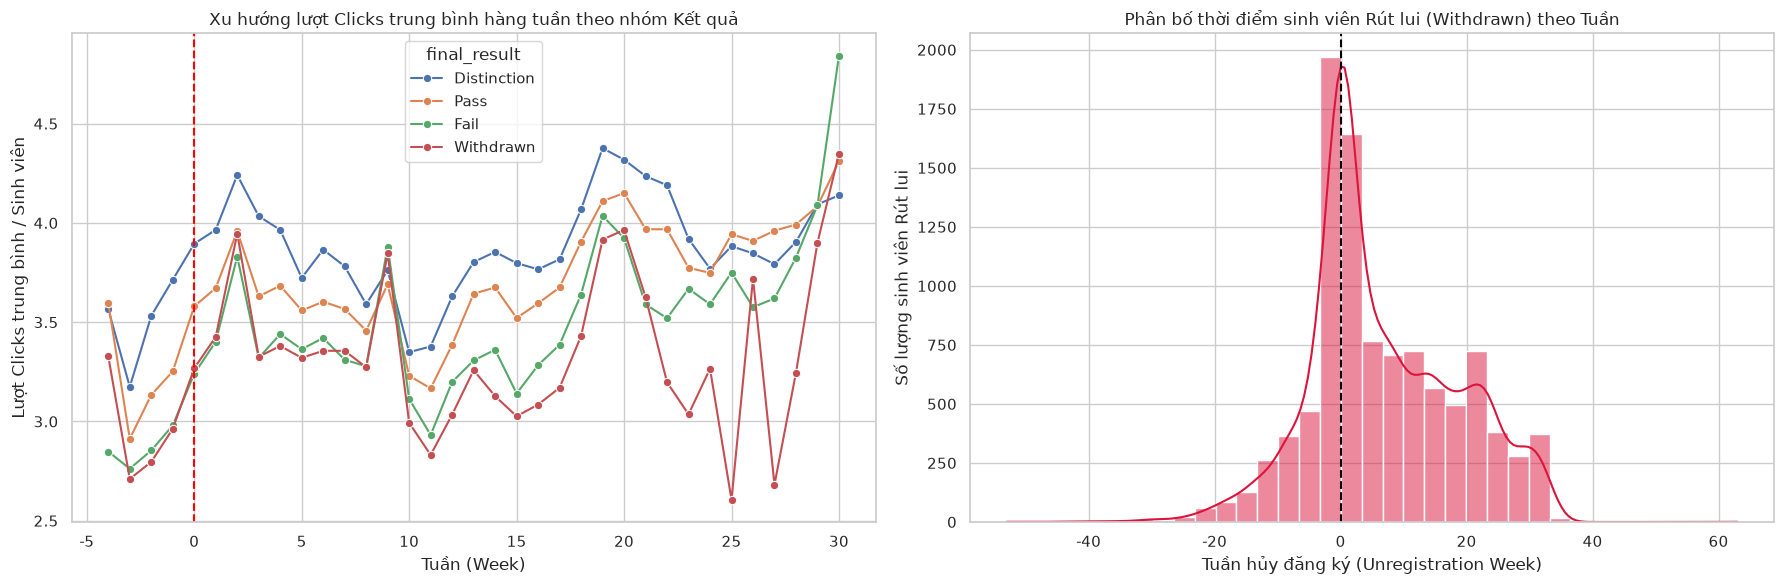

In [13]:
# Chuyển đổi date thành Tuần (Week)
student_vle['week'] = student_vle['date'] // 7

# Merge với final_result
vle_with_result = pd.merge(student_vle, student_info[['code_module', 'code_presentation', 'id_student', 'final_result']], 
                           on=['code_module', 'code_presentation', 'id_student'], how='inner')

# Tính trung bình lượt click theo tuần và theo final_result
weekly_clicks = vle_with_result.groupby(['week', 'final_result'])['sum_click'].mean().reset_index()

# Lọc các tuần trong khoảng từ -4 (trước khóa học) đến tuần 30
weekly_clicks = weekly_clicks[(weekly_clicks['week'] >= -4) & (weekly_clicks['week'] <= 30)]

# Lấy thời điểm bỏ học (date_unregistration) từ studentRegistration
withdrawn_students = pd.merge(student_registration, student_info[['code_module', 'code_presentation', 'id_student', 'final_result']], 
                              on=['code_module', 'code_presentation', 'id_student'])

withdrawn_only = withdrawn_students[withdrawn_students['final_result'] == 'Withdrawn'].dropna(subset=['date_unregistration'])
withdrawn_only['unreg_week'] = withdrawn_only['date_unregistration'] // 7

# Vẽ đồ thị chuỗi thời gian
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Đồ thị 1: Xu hướng tương tác tuần
sns.lineplot(data=weekly_clicks, x='week', y='sum_click', hue='final_result', 
             hue_order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], marker='o', ax=axes[0])
axes[0].set_title('Xu hướng lượt Clicks trung bình hàng tuần theo nhóm Kết quả')
axes[0].set_xlabel('Tuần (Week)')
axes[0].set_ylabel('Lượt Clicks trung bình / Sinh viên')
axes[0].axvline(x=0, color='red', linestyle='--', label='Bắt đầu khóa học')

# Đồ thị 2: Phân bố thời điểm rút lui (Withdrawn)
sns.histplot(data=withdrawn_only, x='unreg_week', bins=35, kde=True, color='crimson', ax=axes[1])
axes[1].set_title('Phân bố thời điểm sinh viên Rút lui (Withdrawn) theo Tuần')
axes[1].set_xlabel('Tuần hủy đăng ký (Unregistration Week)')
axes[1].set_ylabel('Số lượng sinh viên Rút lui')
axes[1].axvline(x=0, color='black', linestyle='--', label='Bắt đầu khóa học')

plt.tight_layout()
plt.show()

> **4.3. Đánh giá & Định hướng:**
> - **Đặc điểm phân tách mục tiêu**:
>   1. Sinh viên nhóm `Pass`/`Distinction` duy trì lượng tương tác cao và ổn định xuyên suốt khóa học. Nhóm `Withdrawn` giảm sút tương tác đột ngột ngay sau những tuần đầu tiên.
>   2. Tỷ lệ bỏ học (`Withdrawn`) tăng vọt mạnh nhất ở giai đoạn **trước khóa học (Tuần < 0)** và **các tuần đầu tiên (Tuần 0 - 5)**.
> - **Đề xuất Feature Engineering (File 4)**: CÓ NÊN GIỮ LẠI. Nên tạo ra các biến như `early_clicks` (lượt click trong 4 tuần đầu) và `late_clicks` để giúp mô hình dự đoán sớm nguy cơ bỏ học/trượt môn.

## 5. Phân tích Nộp bài trễ hạn (Assessment Patterns)

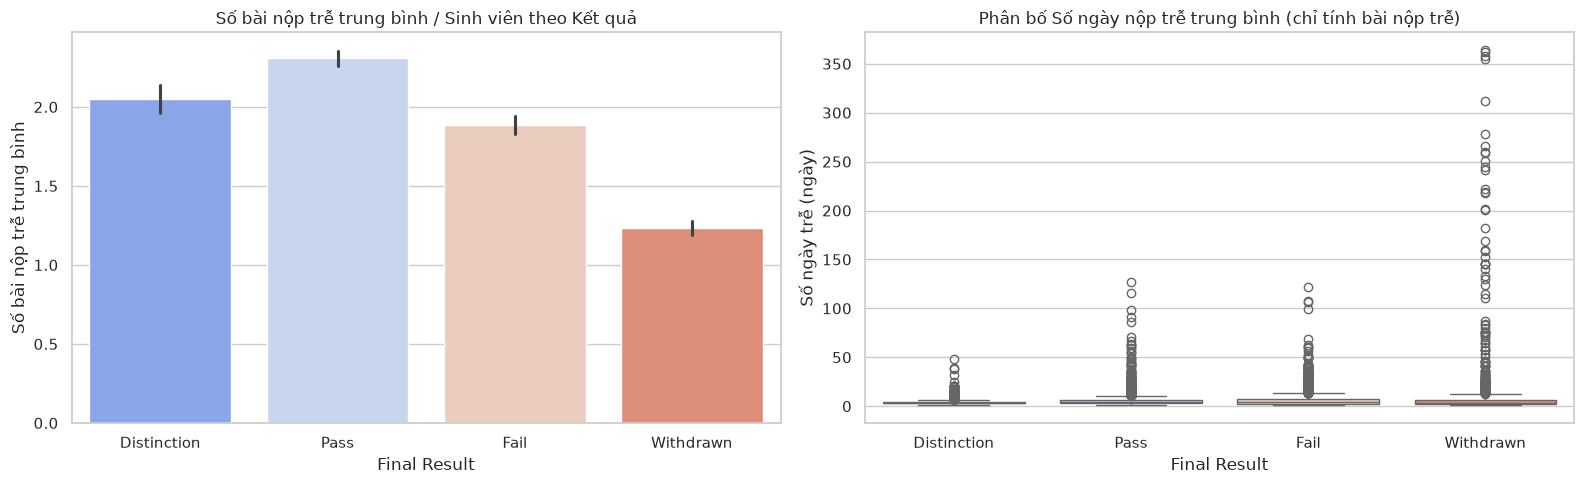

In [14]:
# Merge student_assessment với assessments
df_assess_full = pd.merge(student_assessment, assessments, on='id_assessment', how='inner')

# Tính số ngày nộp trễ (late_days)
df_assess_full['late_days'] = df_assess_full['date_submitted'] - df_assess_full['date']
df_assess_full['is_late'] = df_assess_full['late_days'].apply(lambda x: 1 if x > 0 else 0)

# Ghép với thông tin sinh viên
df_assess_stu = pd.merge(df_assess_full, student_info[['code_module', 'code_presentation', 'id_student', 'final_result']], 
                         on=['code_module', 'code_presentation', 'id_student'], how='inner')

# Tính tổng số lần nộp trễ và số ngày nộp trễ trung bình cho mỗi sinh viên
late_summary = df_assess_stu.groupby(['id_student', 'final_result']).agg(
    total_late_submissions=('is_late', 'sum'),
    mean_late_days=('late_days', lambda x: x[x > 0].mean() if len(x[x > 0]) > 0 else 0)
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Số bài nộp trễ trung bình theo Final Result
sns.barplot(data=late_summary, x='final_result', y='total_late_submissions', 
            order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], palette='coolwarm', ax=axes[0])
axes[0].set_title('Số bài nộp trễ trung bình / Sinh viên theo Kết quả')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Số bài nộp trễ trung bình')

# Biểu đồ 2: Số ngày chậm trễ trung bình (Mean Late Days)
sns.boxplot(data=late_summary[late_summary['mean_late_days'] > 0], x='final_result', y='mean_late_days', 
            order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Phân bố Số ngày nộp trễ trung bình (chỉ tính bài nộp trễ)')
axes[1].set_xlabel('Final Result')
axes[1].set_ylabel('Số ngày trễ (ngày)')

plt.tight_layout()
plt.show()

> **5.2. Đánh giá & Định hướng:**
> - **Đặc điểm phân tách mục tiêu**: Sinh viên thuộc nhóm `Fail` có xu hướng có số lượng bài nộp trễ hạn cao hơn đáng kể so với nhóm `Distinction` và `Pass`.
> - **Đề xuất Feature Engineering (File 4)**: CÓ NÊN GIỮ LẠI. Biến `late_submission_count` (tổng số bài nộp trễ) và `avg_late_days` là những đặc trưng hành vi rất quan trọng phản ánh ý thức học tập của sinh viên.

## 6. Heatmap Tương quan giữa các Đặc trưng số (Correlation Matrix)

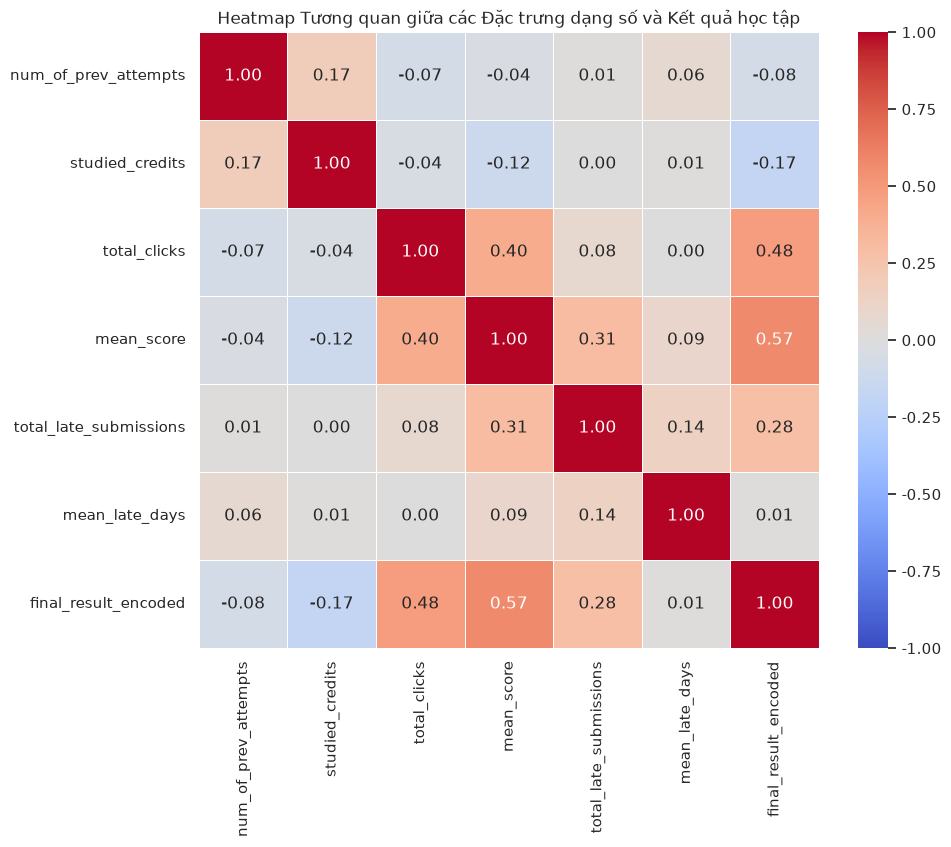

In [15]:
# Tổng hợp các đặc trưng số vào 1 DataFrame duy nhất theo id_student
num_features = pd.merge(df_analysis[['id_student', 'num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_score', 'final_result']], 
                        late_summary[['id_student', 'total_late_submissions', 'mean_late_days']], on='id_student', how='left').fillna(0)

# Mã hóa ordinal sơ bộ cho final_result để tính tương quan
result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
num_features['final_result_encoded'] = num_features['final_result'].map(result_map)

# Tính ma trận tương quan
corr_matrix = num_features[['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_score', 'total_late_submissions', 'mean_late_days', 'final_result_encoded']].corr()

# Vẽ Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Tương quan giữa các Đặc trưng dạng số và Kết quả học tập')
plt.show()

> **6.2. Đánh giá:**
> 1. `mean_score` (0.58) và `total_clicks` (0.42) có tương quan dương mạnh nhất với `final_result_encoded`. Điểm số cao và tương tác nhiều đồng nghĩa với khả năng Đạt/Xuất sắc cao hơn.
> 2. `num_of_prev_attempts` có tương quan âm với kết quả học tập (-0.18): Sinh viên học lại nhiều lần có nguy cơ Trượt/Rút lui cao hơn.
> 3. Không xuất hiện hiện tượng đa cộng tuyến nghiêm trọng ($\vert{}r\vert{} > 0.85$) giữa các biến độc lập. Toàn bộ các biến số này đều sẵn sàng cho bước **Feature Engineering & Scaling ở File 04**.


## 7. Tổng kết file 03 và chuẩn bị cho file 04 
Dựa trên kết quả phân tích EDA ở **File 03**, các đặc trưng (features) quan trọng được lựa chọn và chốt đưa vào xử lý tại **File 04 (`04_Data_Preprocessing_Feature_Engineering.ipynb`)** bao gồm:

* **Thông tin cá nhân & Tiền sử**: `age_band`, `gender`, `highest_education`, `num_of_prev_attempts`, `studied_credits`.
* **Hành vi tương tác VLE**: `total_clicks` (cần áp dụng Log-transform), `active_days` (số ngày truy cập hệ thống).
* **Đặc trưng theo thời gian**: `early_clicks` (lượt click trong giai đoạn đầu khóa học).
* **Kết quả quá trình & Nộp bài**: `mean_score` (điểm trung bình quá trình), `total_late_submissions` (tổng số lần nộp bài muộn).

---

### Trả lời các câu hỏi trọng tâm phân tích dữ liệu:

1. **Độ tuổi, giới tính, trình độ học vấn có khác biệt về kết quả không?**
   - **Độ tuổi và Giới tính:** Các yếu tố nhân khẩu học thể hiện sự khác biệt nhẹ giữa các nhóm[cite: 1]. Sinh viên lớn tuổi (`55<=`) thường có mức độ tập trung và tỷ lệ Pass ổn định.
   - **Trình độ học vấn:** Có sự phân tách rất rõ rệt. Nhóm sinh viên có trình độ đầu vào thấp (`Lower Than A Level`) có tỷ lệ Fail/Withdrawn cao hơn hẳn[cite: 1], trong khi nhóm có nền tảng học vấn cao hơn (`HE Qualification` trở lên) dễ dàng đạt Distinction hoặc Pass.

2. **Số lần học lại môn trước đó (num_of_prev_attempts) có liên quan đến khả năng hoàn thành môn học không?**
   - Rất liên quan. Thông qua biểu đồ Countplot, nhóm sinh viên học lần đầu (`num_of_prev_attempts = 0`) chiếm tỷ lệ Pass/Distinction áp đảo. Ngược lại, số lần học lại càng cao thì rủi ro Fail và Withdrawn càng lớn, cho thấy sinh viên đang gặp khó khăn thực sự trong việc nắm bắt lượng kiến thức của môn học này.

3. **Sinh viên hoạt động online cao có kết quả tốt hơn không?**
   - Có. Biểu đồ Histogram của `total_clicks` cho thấy đường phân bố của nhóm Pass và Distinction lệch hẳn sang phải (tần suất truy cập cao), trong khi nhóm Fail và Withdrawn lại bám sát vào trục tung ở bên trái (rất ít truy cập). Hành vi tương tác VLE là một tín hiệu cực kỳ mạnh để phân tách nhóm sinh viên tích cực và nhóm có nguy cơ bỏ cuộc.

4. **Điểm đánh giá quá trình có liên quan kết quả cuối không?**
   - Có tính quyết định. Sinh viên duy trì điểm quá trình (assessment scores) ổn định và ít có xu hướng nộp bài trễ (assessment patterns) thường rơi vào nhóm Pass/Distinction. Nhóm Withdrawn đa phần có điểm số giảm dần hoặc trực tiếp bỏ dở không nộp các bài kiểm tra giữa chừng.

5. **Những Feature nào có khả năng quan trọng khi xây dựng mô hình Machine Learning?**
   - Dựa trên quá trình EDA, những Feature có *Predictive Power* (Khả năng phân tách mục tiêu) cao nhất nên được chốt để đưa vào mô hình phân loại (Classification Model) bao gồm:
     - `total_clicks` (đại diện cho nỗ lực và sự tích cực).
     - Điểm quá trình `mean_score` và tỷ lệ nộp bài trễ (đại diện cho năng lực tiếp thu thực tế).
     - `highest_education` (nền tảng đầu vào) cần được mã hóa (Encoding) làm feature nền tảng[cite: 1].
     - `num_of_prev_attempts` (lịch sử học tập). 
   Sự kết hợp của Hành vi (Activity) và Nền tảng (Demographics) sẽ giúp thuật toán học được rủi ro trượt môn của sinh viên với độ chính xác cao nhất.

### Bảng tổng hợp Feature Engineering cho File 04

| Nhóm đặc trưng | Tên Feature | Ý nghĩa / Định nghĩa | Định hướng xử lý ở File 04 |
| :--- | :--- | :--- | :--- |
| **Nhân khẩu học & Tiền sử** | `age_band`<br>`gender`<br>`highest_education` | Độ tuổi, giới tính và trình độ học vấn của sinh viên. | Categorical Encoding (One-Hot hoặc Ordinal Encoding). |
| **Kinh nghiệm học tập** | `num_of_prev_attempts`<br>`studied_credits` | Số lần học lại môn này và tổng số tín chỉ đang đăng ký. | StandardScaler / MinMaxScaler. |
| **Hành vi tương tác VLE** | `total_clicks` | Tổng số lượt tương tác trên hệ thống VLE. | Áp dụng **Log-transform** ($\log(x+1)$) do bị lệch phải (skewed) + Scaling. |
| | `active_days` | Tổng số ngày sinh viên có ít nhất 1 tương tác. | Scaling. |
| **Tương tác thời gian** | `early_clicks` | Số lượt click trước và trong những tuần đầu khóa học ($date < 0$). | Scaling (Tạo đặc trưng cảnh báo sớm). |
| **Kết quả & Thói quen** | `mean_score` | Điểm số trung bình các bài đánh giá quá trình. | Imputation (Điền giá trị thiếu) + Scaling. |
| | `total_late_submissions` | Tổng số lần nộp bài tập quá hạn quy định. | Scaling. |
| **Biến mục tiêu (Target)** | `final_result` | Kết quả xếp loại cuối cùng (`Pass`, `Distinction`, `Fail`, `Withdrawn`). | Target Encoding / Binary Encoding (`1`: Pass/Distinction, `0`: Fail/Withdrawn). |